In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import spacy
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn import neighbors
from sklearn.ensemble import RandomForestClassifier
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/thngonquang/semeval14-augment/data_1 - negative_expanded.csv
/kaggle/input/datasets/thngonquang/semeval14-augment/train.csv
/kaggle/input/datasets/thngonquang/semeval14-augment/test.csv
/kaggle/input/datasets/thngonquang/semeval14-augment/data_1 - neutral_expanded.csv


In [2]:
df_train_root = pd.read_csv("/kaggle/input/datasets/thngonquang/semeval14-augment/train.csv", encoding='utf8')
df_negative_augment = pd.read_csv("/kaggle/input/datasets/thngonquang/semeval14-augment/data_1 - negative_expanded.csv")
df_neutral_augment = pd.read_csv("/kaggle/input/datasets/thngonquang/semeval14-augment/data_1 - neutral_expanded.csv")
df_test =  pd.read_csv("/kaggle/input/datasets/thngonquang/semeval14-augment/test.csv")

#  Gộp lại tập train

In [3]:
df_neutral_augment

,Sentence,Aspect Term,polarity,augmented_sentences
0,"this is the best secret place in midtown', I h...",bar,neutral,I was told by the bartender that this is midto...
1,"this is the best secret place in midtown', I h...",bar,neutral,The bartender mentioned this is the top secret...
2,"this is the best secret place in midtown', I h...",bar,neutral,"According to the bartender, this place is midt..."
3,"not the food ,not the ambiance , not the servi...",ambiance,neutral,I concur with earlier reviews: endless waiting...
4,"not the food ,not the ambiance , not the servi...",ambiance,neutral,"Like others said, you stand around forever, th..."
...,...,...,...,...
1531,"It took half an hour to get our check, which w...",check,neutral,It required thirty minutes to receive our chec...
1532,"It took half an hour to get our check, which w...",check,neutral,"We waited half an hour for the check, and that..."
1533,"I've eaten thai many times, and am very famili...",cuisine,neutral,"I've had Thai food on many occasions, so I'm q..."
1534,"I've eaten thai many times, and am very famili...",cuisine,neutral,"Having tried Thai dishes repeatedly, I know th..."


In [4]:
df_negative_augment = df_negative_augment.sample(n=1100, random_state=42).reset_index(drop=True)
df_neutral_augment = df_neutral_augment.sample(n=1200, random_state=42).reset_index(drop=True)

In [5]:
# Đổi tên các cột của data Agment :v
df_negative_augment = df_negative_augment.drop([ 'Sentence'], axis=1)

df_negative_augment = df_negative_augment.rename(columns={
    "augmented_sentences": "Sentence",
})
df_neutral_augment = df_neutral_augment.drop([ 'Sentence'], axis=1)

df_neutral_augment = df_neutral_augment.rename(columns={
    "augmented_sentences": "Sentence",
})

# Ghép Data train lại nè
df = pd.concat([df_train_root, df_negative_augment, df_neutral_augment], ignore_index=True)

In [6]:
labels = df['polarity'].unique().tolist()
label_map = {label: i for i, label in enumerate(labels)}
num_labels = len(labels)

df['labels'] = df['polarity'].map(label_map)
df_test['labels'] = df_test['polarity'].map(label_map)

print(f"Number of labels: {num_labels}")
print(f"Label mapping: {label_map}")

Number of labels: 4
Label mapping: {'negative': 0, 'positive': 1, 'neutral': 2, 'conflict': 3}


In [7]:
# drop polarity
df = df.drop(columns=['polarity'])
df_test = df_test.drop(columns=['polarity'])


In [8]:
label_names = ['negative', 'positive', 'neutral']

In [9]:
# df_merge = df['Sentence'] + ' [asp] ' + df['Aspect Term']
# df = pd.concat([df, df_merge.rename('sentence')], axis=1)

In [10]:
df = df[df['labels'] != 3]
df_test = df_test[df_test['labels'] != 3]

# **Augment Data**

In [11]:
train_df = df.copy()
test_df = df_test.copy()

# Giữ bản raw cho BERT (chưa preprocessing)
train_df_raw = df.copy()
test_df_raw = df_test.copy()


In [12]:
train_df

,Sentence,Aspect Term,labels
0,"Small servings for main entree, i had salmon (...",salmon,0
1,The food inludes famous scrumptious bombay sty...,bhelpuri,1
2,It is so easy to get a reservation at a top pl...,reservation,1
3,"this is the best secret place in midtown', I h...",bar,2
4,I loved everythig about it-especially the show...,shows,1
...,...,...,...
5249,"While walking around the village, we dropped i...",drinks,2
5250,"Though not typical restaurant food, the chef r...",cuisine,2
5251,I have never eaten 40 pieces of fairly decent ...,nigiri,2
5252,"The food was nothing noteworthy, so we just ha...",food,2


In [13]:
test_df

,Sentence,Aspect Term,labels
0,"Based on the reviews for dinner, this is a pla...",Dim Sum,0
1,Just because it's cheap does NOT mean the port...,portions,1
2,This place would be so much better served by b...,served,0
3,The atmosphere is great!!!,atmosphere,1
4,I went at 6:00 PM specifically for the pre-the...,pre-theater menu,1
...,...,...,...
734,Both times we waited well over a half hour for...,reservations,0
735,I complete the total bagel experience by havin...,bagel,1
736,The worst excuse for Japanese food I've ever e...,Japanese food,0
737,"The signs, the specials menus, food, and even ...",signs,1


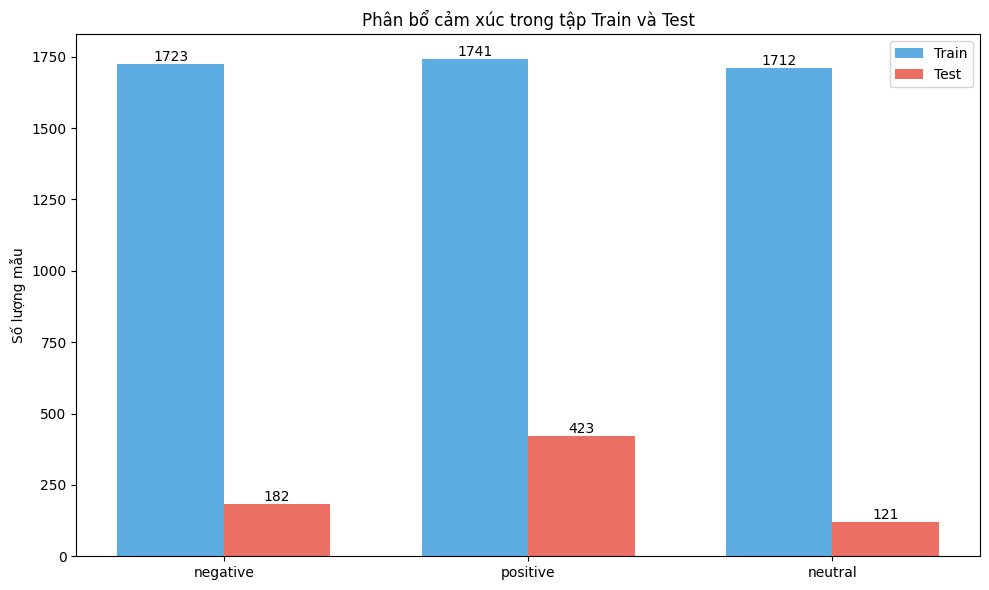

In [14]:
import matplotlib.pyplot as plt

def plot_sentiment_distribution(train_series, test_series):
    train_counts = train_series.value_counts().sort_index()
    test_counts  = test_series.value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(10, 6))
    x = range(len(train_counts))
    width = 0.35
    ax.bar([i - width/2 for i in x], train_counts.values, width, label="Train", alpha=0.8, color="#3498db")
    ax.bar([i + width/2 for i in x], test_counts.values,  width, label="Test",  alpha=0.8, color="#e74c3c")

    ax.set_ylabel("Số lượng mẫu")
    ax.set_title("Phân bổ cảm xúc trong tập Train và Test")
    ax.set_xticks(list(x))
    ax.set_xticklabels(label_names)
    ax.legend()

    for i, v in enumerate(train_counts.values):
        ax.text(i - width/2, v, str(v), ha="center", va="bottom")
    for i, v in enumerate(test_counts.values):
        ax.text(i + width/2, v, str(v), ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

plot_sentiment_distribution(train_df["labels"], test_df["labels"])


# **Processing Data**

## Lower

In [15]:
train_df['Sentence'] = train_df['Sentence'].str.lower()
test_df['Sentence'] = test_df['Sentence'].str.lower()

## Loại bỏ punc

In [16]:
# nlp được load ở cell bên dưới cùng với stop_words


In [17]:
def remove_punc_spacy(text):
    doc = nlp(text)
    return " ".join([token.text for token in doc if not token.is_punct])

## Lemmatizaion

In [18]:
def func_lemma(text):
    doc = nlp(text)
    
    tmp = ""
    
    for token in doc:
        tmp += token.lemma_ + " "
    
    return tmp.strip()

## Stopwords

In [19]:
KEEP_WORDS = [
    # negation
    'not', 'no', 'never', 'none', 'nobody', 'nothing',
    'neither', 'nor', 'cannot', 'without',
    "n't", 'n’t', 'ca', 'noone',

    # intensity
    'very', 'too', 'so', 'quite', 'really',
    'most', 'least', 'less', 'much', 'enough',
    'almost', 'pretty',

    # contrast
    'but', 'however', 'although', 'though',
    'nevertheless', 'yet', 'whereas',

    # frequency
    'always', 'often', 'sometimes', 'ever'
]


In [20]:
nlp = spacy.load("en_core_web_sm")

stop_words = nlp.Defaults.stop_words

In [21]:
sw = [word for word in stop_words if word not in KEEP_WORDS]
print("stopword ban đầu: ", len(stop_words))
print("stopword sau khi loại bỏ: ", len(sw))

stopword ban đầu:  326
stopword sau khi loại bỏ:  290


In [22]:
def remove_stopwords(text):
    word_list = text.split()
    filtered_words = [word for word in word_list if word not in sw]
    filtered_text = ' '.join(filtered_words)
    return filtered_text

remove_stopwords("I am running a marathon and I have run many before.")

'I running marathon I run before.'

In [23]:
train_df['Sentence'] = train_df['Sentence'].apply(remove_stopwords)
train_df['Sentence'] = train_df['Sentence'].apply(func_lemma)
train_df['Sentence'] = train_df['Sentence'].apply(remove_punc_spacy)

In [24]:
test_df['Sentence'] = test_df['Sentence'].apply(remove_stopwords)
test_df['Sentence'] = test_df['Sentence'].apply(func_lemma)
test_df['Sentence'] = test_df['Sentence'].apply(remove_punc_spacy)

# 2. **Vector hóa**

In [25]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),     # unigram + bigram
    # max_features=15000,    # giới hạn vocab
)
X_train_vectors = vectorizer.fit_transform(train_df['Sentence'])
X_test_vectors = vectorizer.transform(test_df['Sentence'])

In [26]:
# Confusion matrix
def p_cm(y_true, y_pred, model_name=''):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    title = f'{model_name} - ' if model_name else ''

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=label_names, yticklabels=label_names)
    axes[0].set_title(f'{title}Confusion Matrix (Counts)')
    axes[0].set_ylabel('Thực tế (Actual)')
    axes[0].set_xlabel('Dự đoán (Predicted)')

    # Normalized
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=label_names, yticklabels=label_names,
                vmin=0, vmax=1)
    axes[1].set_title(f'{title}Confusion Matrix (Normalized)')
    axes[1].set_ylabel('Thực tế (Actual)')
    axes[1].set_xlabel('Dự đoán (Predicted)')

    plt.tight_layout()
    plt.show()


# Naive Bayes

In [27]:
# Định nghĩa y_train, y_test dùng chung cho tất cả models
y_train = train_df["labels"]
y_test  = test_df["labels"]


In [28]:
model = MultinomialNB()

model.fit(X_train_vectors, train_df['labels'])

MultinomialNB()

In [29]:
y_pred_nb = model.predict(X_test_vectors)

accuracy = accuracy_score(test_df['labels'], y_pred_nb)
print(f"Độ chính xác của mô hình: {accuracy}")

nb_report = classification_report(test_df['labels'], y_pred_nb, output_dict = True)
print(classification_report(test_df['labels'], y_pred_nb))

Độ chính xác của mô hình: 0.7066115702479339
              precision    recall  f1-score   support

           0       0.68      0.54      0.60       182
           1       0.82      0.83      0.82       423
           2       0.42      0.53      0.47       121

    accuracy                           0.71       726
   macro avg       0.64      0.63      0.63       726
weighted avg       0.72      0.71      0.71       726



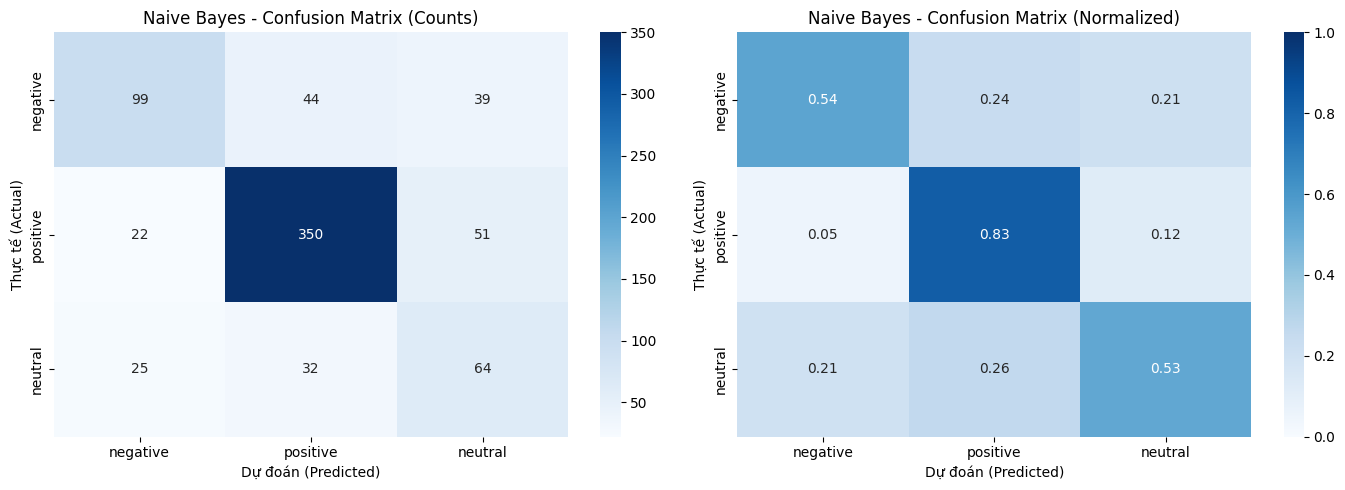

In [30]:
p_cm(y_test, y_pred_nb, 'Naive Bayes')


# Logistic Regression

In [31]:
model = LogisticRegression(max_iter=1000, random_state=42) # class_weight='balanced' => Không tốt, khả năng dữ liệu test cũng bị lệch nhiều

model.fit(X_train_vectors, train_df['labels'])

LogisticRegression(max_iter=1000, random_state=42)

In [32]:
y_pred_lr = model.predict(X_test_vectors)

accuracy = accuracy_score(test_df['labels'], y_pred_lr)
print(f"Độ chính xác của mô hình: {accuracy}")

lr_report = classification_report(test_df['labels'], y_pred_lr, output_dict = True)
print(classification_report(test_df['labels'], y_pred_lr))

Độ chính xác của mô hình: 0.721763085399449
              precision    recall  f1-score   support

           0       0.67      0.57      0.61       182
           1       0.84      0.84      0.84       423
           2       0.44      0.55      0.49       121

    accuracy                           0.72       726
   macro avg       0.65      0.65      0.65       726
weighted avg       0.73      0.72      0.73       726



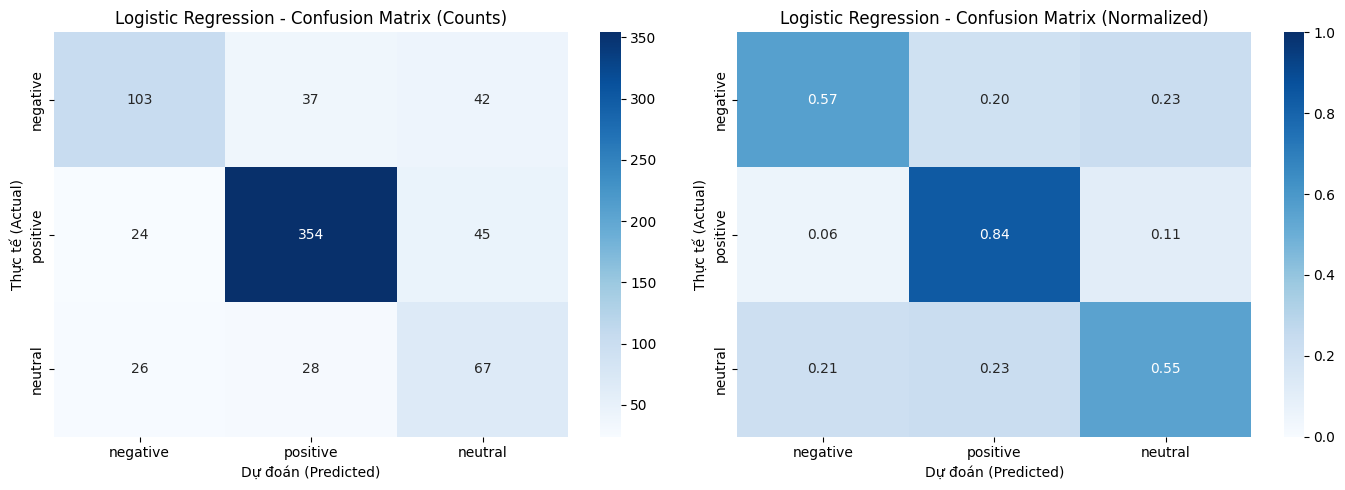

In [33]:
p_cm(y_test, y_pred_lr, 'Logistic Regression')


# SVM

In [34]:
# Scikit-learn tự động hiểu y_train có 4 lớp và áp dụng OvO
model = SVC(kernel='linear', decision_function_shape='ovo')
model.fit(X_train_vectors, train_df['labels'])

SVC(decision_function_shape='ovo', kernel='linear')

In [35]:
y_pred_svm = model.predict(X_test_vectors)

accuracy = accuracy_score(test_df['labels'], y_pred_svm)
print(f"Độ chính xác của mô hình: {accuracy}")

svm_report = classification_report(test_df['labels'], y_pred_svm, output_dict = True)
print(classification_report(test_df['labels'], y_pred_svm))

Độ chính xác của mô hình: 0.7121212121212122
              precision    recall  f1-score   support

           0       0.64      0.57      0.60       182
           1       0.84      0.83      0.84       423
           2       0.43      0.53      0.47       121

    accuracy                           0.71       726
   macro avg       0.64      0.64      0.64       726
weighted avg       0.72      0.71      0.72       726



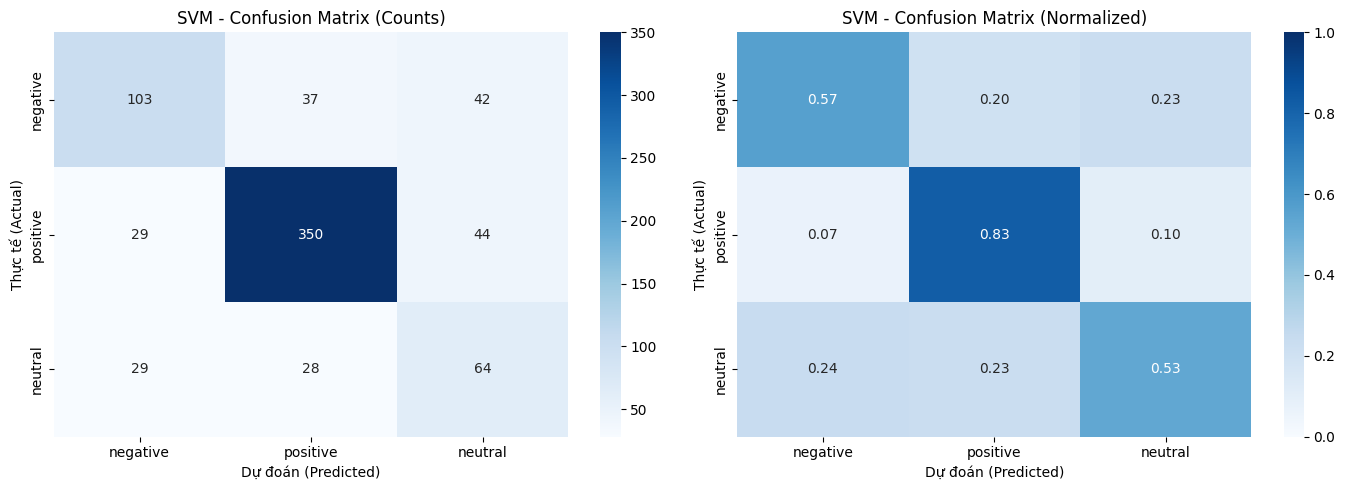

In [36]:
p_cm(y_test, y_pred_svm, 'SVM')


# KNN

In [37]:
def myweight(distances):
    sigma2 = 0.3
    return np.exp(-distances ** 2 / sigma2)

In [38]:
model = neighbors.KNeighborsClassifier(n_neighbors = 7, p = 2, weights = myweight)
model.fit(X_train_vectors, train_df['labels'])

KNeighborsClassifier(n_neighbors=7,
                     weights=<function myweight at 0x79a4dc7a7ce0>)

In [39]:
y_pred_knn = model.predict(X_test_vectors)

accuracy = accuracy_score(test_df['labels'], y_pred_knn)
print(f"Độ chính xác của mô hình: {accuracy}")

knn_report = classification_report(test_df['labels'], y_pred_knn, output_dict = True)
print(classification_report(test_df['labels'], y_pred_knn))

Độ chính xác của mô hình: 0.6955922865013774
              precision    recall  f1-score   support

           0       0.65      0.55      0.60       182
           1       0.82      0.82      0.82       423
           2       0.40      0.50      0.44       121

    accuracy                           0.70       726
   macro avg       0.62      0.62      0.62       726
weighted avg       0.71      0.70      0.70       726



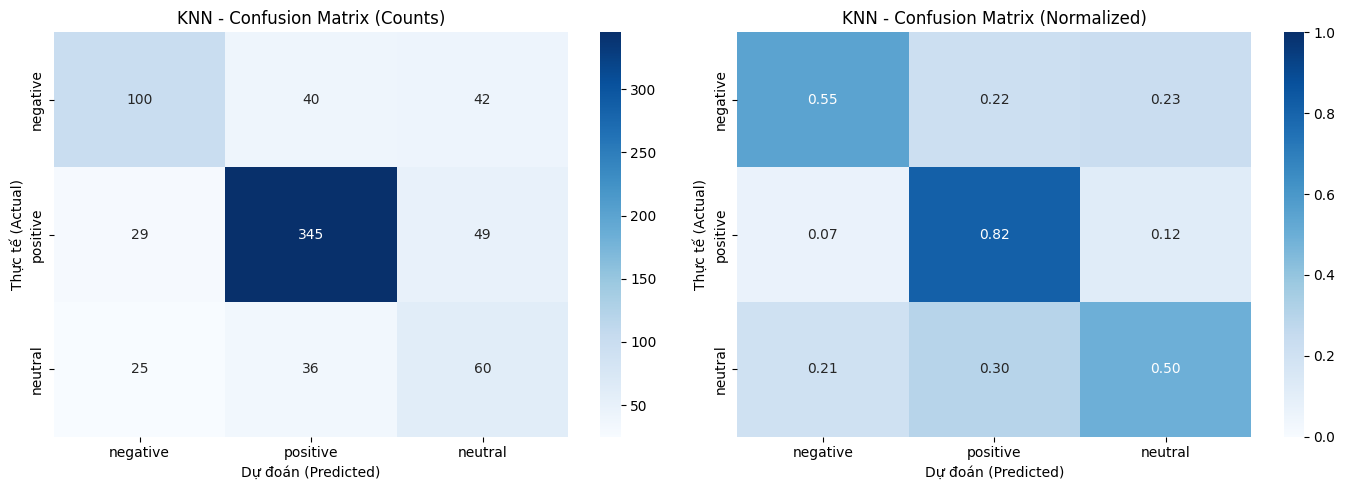

In [40]:
p_cm(y_test, y_pred_knn, 'KNN')


# Random Forest

In [41]:
# y_train và y_test đã được định nghĩa ở trên


In [42]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_vectors, y_train)

RandomForestClassifier(random_state=42)

In [43]:
y_pred_rd = model.predict(X_test_vectors)

accuracy = accuracy_score(y_test, y_pred_rd)
print(f"Độ chính xác của mô hình: {accuracy}")

rd_report = classification_report(y_test, y_pred_rd, output_dict = True)
print(classification_report(y_test, y_pred_rd))

Độ chính xác của mô hình: 0.7162534435261708
              precision    recall  f1-score   support

           0       0.69      0.55      0.61       182
           1       0.80      0.84      0.82       423
           2       0.46      0.51      0.48       121

    accuracy                           0.72       726
   macro avg       0.65      0.64      0.64       726
weighted avg       0.72      0.72      0.71       726



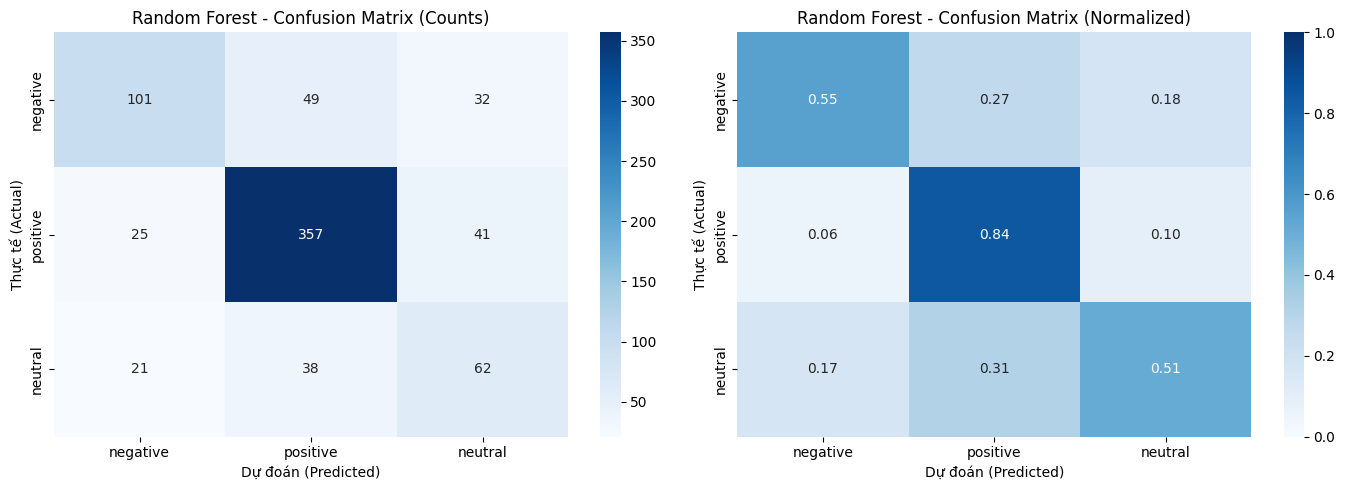

In [44]:
p_cm(y_test, y_pred_rd, 'Random Forest')


              Model  Accuracy  Precision   Recall  F1 (weighted)  F1 (macro)
        Naive Bayes  0.706612   0.717950 0.706612       0.709296    0.631204
Logistic Regression  0.721763   0.733533 0.721763       0.725287    0.647684
                SVM  0.712121   0.722877 0.712121       0.715976    0.636077
                KNN  0.695592   0.706474 0.695592       0.699082    0.617983
      Random Forest  0.716253   0.717263 0.716253       0.714472    0.640629


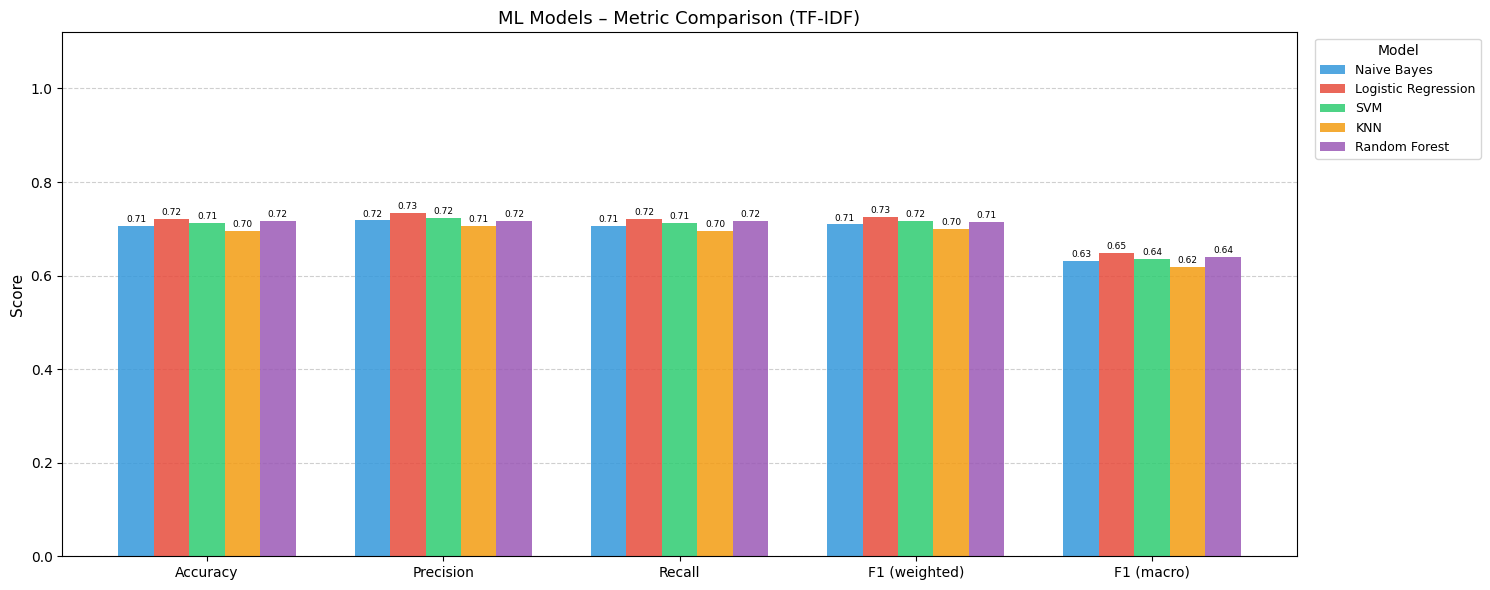

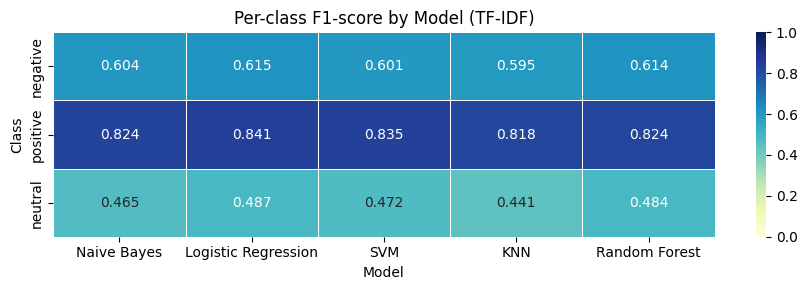

In [45]:
reports = {
    'Naive Bayes': nb_report,
    'Logistic Regression': lr_report,
    'SVM': svm_report,
    'KNN': knn_report,
    'Random Forest': rd_report,
}

results = pd.DataFrame([
    {
        'Model': name,
        'Accuracy':   r['accuracy'],
        'Precision':  r['weighted avg']['precision'],
        'Recall':     r['weighted avg']['recall'],
        'F1 (weighted)': r['weighted avg']['f1-score'],
        'F1 (macro)': r['macro avg']['f1-score'],
    }
    for name, r in reports.items()
])

print(results.to_string(index=False))

# ── Bar chart: Accuracy / Precision / Recall / F1-weighted / F1-macro ──────
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1 (weighted)', 'F1 (macro)']
model_list   = results['Model'].tolist()
colors       = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
x            = np.arange(len(metrics_cols))
n_models     = len(model_list)
width        = 0.15

fig, ax = plt.subplots(figsize=(15, 6))
for i, (mdl, color) in enumerate(zip(model_list, colors)):
    scores = results[results['Model'] == mdl][metrics_cols].values[0]
    offset = (i - n_models / 2 + 0.5) * width
    bars = ax.bar(x + offset, scores, width, label=mdl, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=6.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics_cols, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('ML Models – Metric Comparison (TF-IDF)', fontsize=13)
ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# ── Per-class F1 heatmap ────────────────────────────────────────────────────
per_class_f1 = pd.DataFrame(
    {name: [r[str(i)]['f1-score'] for i in range(3)] for name, r in reports.items()},
    index=label_names
)

fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(per_class_f1, annot=True, fmt='.3f', cmap='YlGnBu',
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Per-class F1-score by Model (TF-IDF)', fontsize=12)
ax.set_xlabel('Model')
ax.set_ylabel('Class')
plt.tight_layout()
plt.show()


In [46]:
lengths = df['Sentence'].str.split().str.len()

print("Min length:", lengths.min())
print("Max length:", lengths.max())
print("Avg length:", lengths.mean())


Min length: 1
Max length: 69
Avg length: 17.73435085007728


# BERT

In [47]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

2026-03-24 04:51:10.774833: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774327871.160230      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774327871.275136      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774327872.419574      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774327872.419617      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774327872.419620      55 computation_placer.cc:177] computation placer alr

In [48]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [49]:
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [50]:
class AspectSentimentDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_len=128):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):

        review = str(self.data.loc[idx, 'Sentence'])
        aspect = str(self.data.loc[idx, 'Aspect Term'])
        label = self.data.loc[idx, 'labels']

        encoding = self.tokenizer(
            review,
            aspect,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [51]:
# Dùng raw data (chưa preprocessing) cho BERT
train_dataset = AspectSentimentDataset(train_df_raw, tokenizer, MAX_LEN)
val_dataset   = AspectSentimentDataset(test_df_raw,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)


In [52]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

model.to(device)

# ========================
# Optimizer
# ========================

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [53]:
# ========================
# Training loop
# ========================
best_f1 = 0
best_epoch = 0
best_preds = None
best_labels = None

for epoch in range(5):

    model.train()
    total_loss = 0

    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} loss:", total_loss)

    # ========================
    # Validation
    # ========================

    model.eval()

    preds = []
    true_labels = []
    
    val_loss = 0
    
    with torch.no_grad():
    
        for batch in val_loader:
    
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
    
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
    
            loss = outputs.loss
            val_loss += loss.item()
    
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)
    
            preds.extend(predictions.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    # Metrics
    accuracy = accuracy_score(true_labels, preds)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels,
        preds,
        average='macro'
    )
    
    avg_val_loss = val_loss / len(val_loader)
    
    print("\nValidation Results")
    print("------------------")
    print(f"Validation Loss: {avg_val_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Save best model
    if f1 > best_f1:
        best_f1 = f1
        best_epoch = epoch + 1
        best_preds = preds
        best_labels = true_labels
    
        torch.save(model.state_dict(), "best_bert_model.pt")
    
        print("🔥 New best model saved!")

from sklearn.metrics import classification_report

print("\n==============================")
print("BEST MODEL RESULTS")
print("==============================")

print(f"Best Epoch: {best_epoch}")
print(f"Best F1-score: {best_f1:.4f}")

print("\nClassification Report:")
print(classification_report(best_labels, best_preds))

Epoch 1 loss: 231.22628206014633

Validation Results
------------------
Validation Loss: 0.5911
Accuracy: 0.7769
Precision: 0.7204
Recall: 0.6932
F1-score: 0.7029
🔥 New best model saved!
Epoch 2 loss: 113.11435360834002

Validation Results
------------------
Validation Loss: 0.5446
Accuracy: 0.8072
Precision: 0.7443
Recall: 0.7513
F1-score: 0.7475
🔥 New best model saved!
Epoch 3 loss: 50.01133176404983

Validation Results
------------------
Validation Loss: 0.7126
Accuracy: 0.7769
Precision: 0.7200
Recall: 0.7621
F1-score: 0.7338
Epoch 4 loss: 31.044084562920034

Validation Results
------------------
Validation Loss: 0.6905
Accuracy: 0.8085
Precision: 0.7457
Recall: 0.7391
F1-score: 0.7421
Epoch 5 loss: 20.312820888357237

Validation Results
------------------
Validation Loss: 0.7672
Accuracy: 0.7920
Precision: 0.7291
Recall: 0.7019
F1-score: 0.7134

BEST MODEL RESULTS
Best Epoch: 2
Best F1-score: 0.7475

Classification Report:
              precision    recall  f1-score   support

   

In [54]:
bert_report = classification_report(best_labels, best_preds, output_dict=True)
results.loc[len(results)] = {
    'Model':         'BERT',
    'Accuracy':      bert_report['accuracy'],
    'Precision':     bert_report['weighted avg']['precision'],
    'Recall':        bert_report['weighted avg']['recall'],
    'F1 (weighted)': bert_report['weighted avg']['f1-score'],
    'F1 (macro)':    bert_report['macro avg']['f1-score'],
}
print(results.to_string(index=False))


              Model  Accuracy  Precision   Recall  F1 (weighted)  F1 (macro)
        Naive Bayes  0.706612   0.717950 0.706612       0.709296    0.631204
Logistic Regression  0.721763   0.733533 0.721763       0.725287    0.647684
                SVM  0.712121   0.722877 0.712121       0.715976    0.636077
                KNN  0.695592   0.706474 0.695592       0.699082    0.617983
      Random Forest  0.716253   0.717263 0.716253       0.714472    0.640629
               BERT  0.807163   0.811087 0.807163       0.808949    0.747524


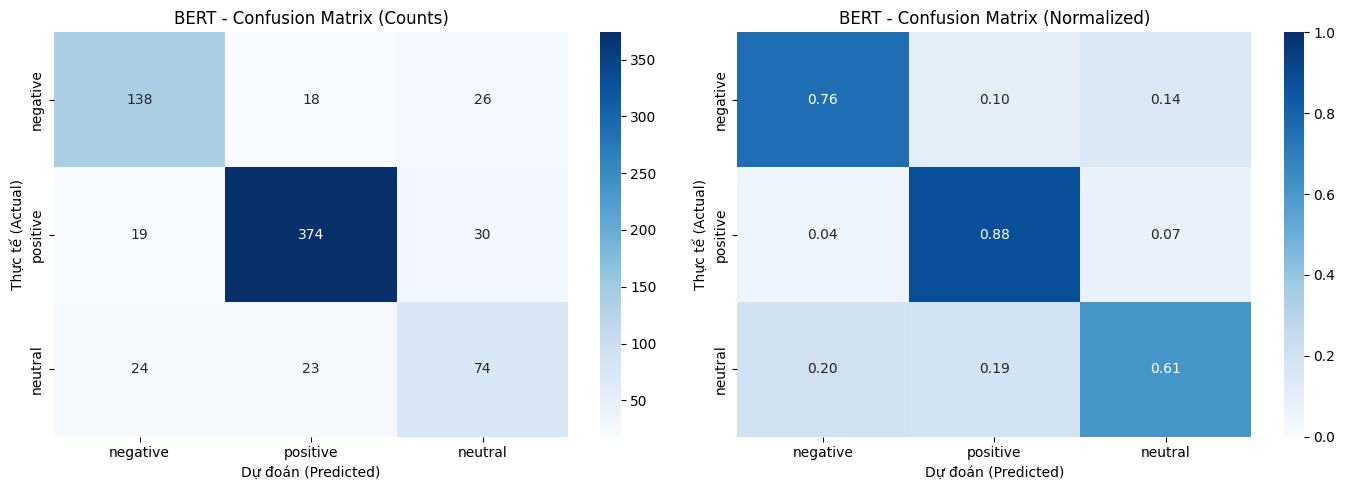

In [55]:
p_cm(best_labels, best_preds, 'BERT')


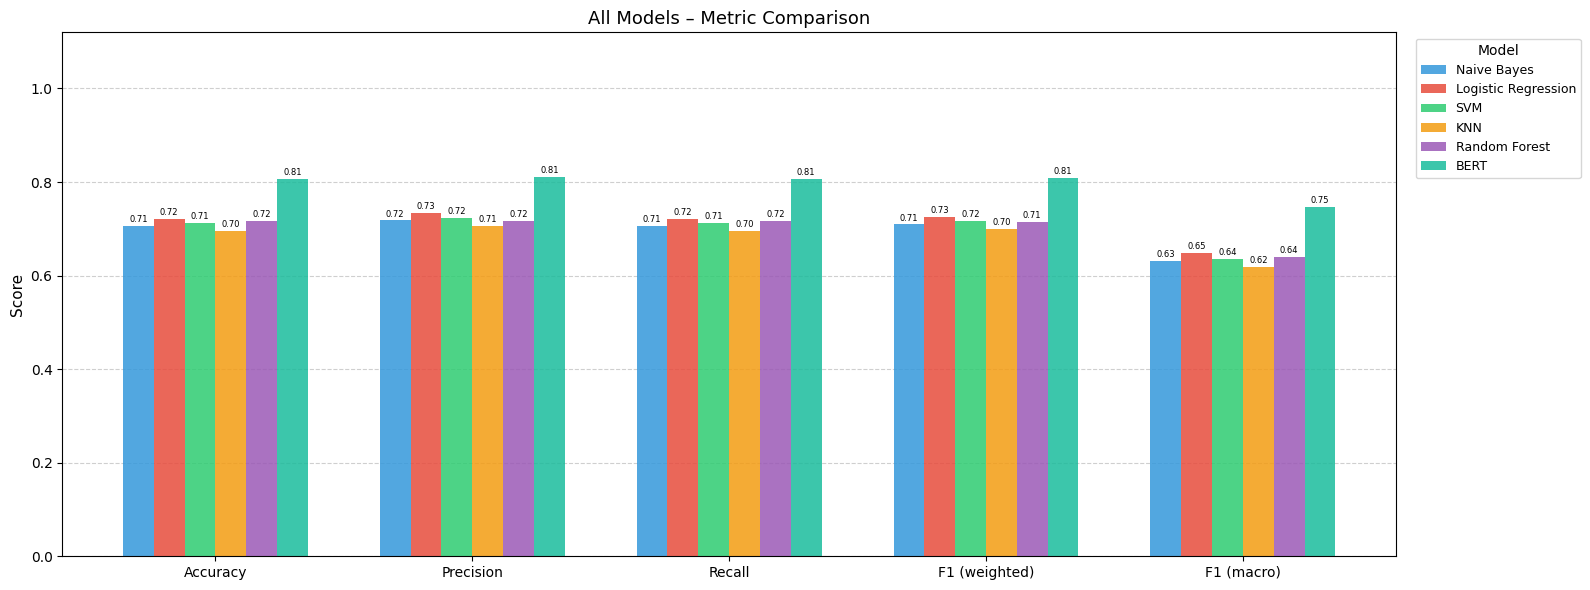

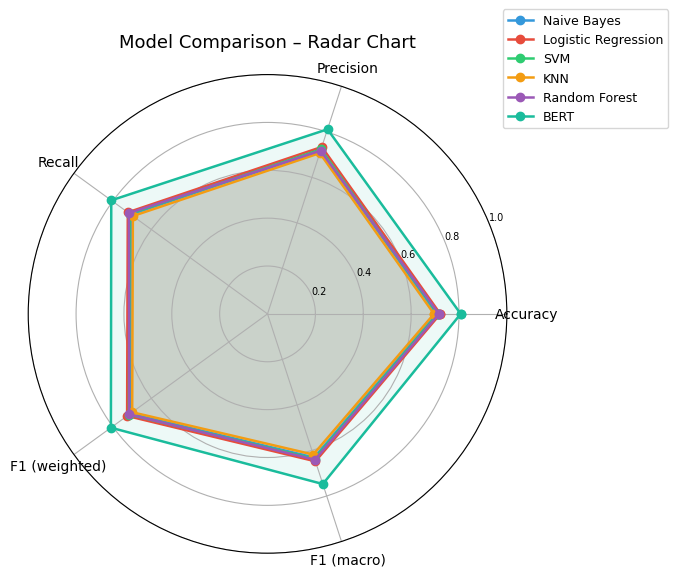

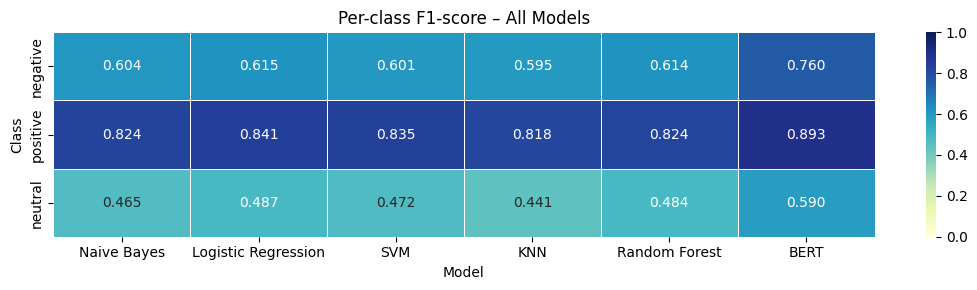

In [56]:
# ── Final bar chart: all models including BERT ─────────────────────────────
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1 (weighted)', 'F1 (macro)']
model_list   = results['Model'].tolist()
colors       = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
x            = np.arange(len(metrics_cols))
n_models     = len(model_list)
width        = 0.12

fig, ax = plt.subplots(figsize=(16, 6))
for i, (mdl, color) in enumerate(zip(model_list, colors)):
    scores = results[results['Model'] == mdl][metrics_cols].values[0]
    offset = (i - n_models / 2 + 0.5) * width
    bars = ax.bar(x + offset, scores, width, label=mdl, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=6)

ax.set_xticks(x)
ax.set_xticklabels(metrics_cols, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('All Models – Metric Comparison', fontsize=13)
ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# ── Radar chart ─────────────────────────────────────────────────────────────
radar_metrics = ['Accuracy', 'Precision', 'Recall', 'F1 (weighted)', 'F1 (macro)']
N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for (_, row), color in zip(results.iterrows(), colors):
    vals = row[radar_metrics].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=1.8, color=color, label=row['Model'])
    ax.fill(angles, vals, alpha=0.08, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7)
ax.set_title('Model Comparison – Radar Chart', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

# ── Per-class F1 heatmap (all models) ───────────────────────────────────────
all_reports = {
    'Naive Bayes':        nb_report,
    'Logistic Regression': lr_report,
    'SVM':                svm_report,
    'KNN':                knn_report,
    'Random Forest':      rd_report,
    'BERT':               bert_report,
}
per_class_f1_all = pd.DataFrame(
    {name: [r[str(i)]['f1-score'] for i in range(3)] for name, r in all_reports.items()},
    index=label_names
)

fig, ax = plt.subplots(figsize=(11, 3))
sns.heatmap(per_class_f1_all, annot=True, fmt='.3f', cmap='YlGnBu',
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Per-class F1-score – All Models', fontsize=12)
ax.set_xlabel('Model')
ax.set_ylabel('Class')
plt.tight_layout()
plt.show()
